<a href="https://colab.research.google.com/github/regmiresearch/ImageProcessingProjects/blob/main/Chapter11/simple_auto_encoder_with_different_latent_size.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install -q torch_snippets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.3/110.3 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.7/184.7 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.5/226.5 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.2/398.2 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 470.5/470.5 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 96.0 MB/s eta 0:00:00


In [2]:

from torch_snippets import *
from torchvision.datasets import MNIST
from torchvision import transforms
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
img_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
    transforms.Lambda(lambda x: x.to(device))
])

In [4]:
trn_ds = MNIST('/content/', transform=img_transform, train=True, download=True)
val_ds = MNIST('/content/', transform=img_transform, train=False, download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 544kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.40MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.6MB/s]


In [5]:
batch_size = 256
trn_dl = DataLoader(trn_ds, batch_size=batch_size, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

In [6]:
class AutoEncoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.latend_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128), nn.ReLU(True),
            nn.Linear(128, 64), nn.ReLU(True),
            #nn.Linear(64, 12),  nn.ReLU(True),
            nn.Linear(64, latent_dim))
        self.decoder = nn.Sequential(
            #nn.Linear(latent_dim, 12), nn.ReLU(True),
            nn.Linear(latent_dim, 64), nn.ReLU(True),
            nn.Linear(64, 128), nn.ReLU(True),
            nn.Linear(128, 28 * 28), nn.Tanh())

    def forward(self, x):
        x = x.view(len(x), -1)
        x = self.encoder(x)
        x = self.decoder(x)
        x = x.view(len(x), 1, 28, 28)
        return x

In [7]:
%pip install torch_summary
from torchsummary import summary
model = AutoEncoder(3).to(device)
summary(model, torch.zeros(2,1,28,28));

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 3]                   --
|    └─Linear: 2-1                       [-1, 128]                 100,480
|    └─ReLU: 2-2                         [-1, 128]                 --
|    └─Linear: 2-3                       [-1, 64]                  8,256
|    └─ReLU: 2-4                         [-1, 64]                  --
|    └─Linear: 2-5                       [-1, 3]                   195
├─Sequential: 1-2                        [-1, 784]                 --
|    └─Linear: 2-6                       [-1, 64]                  256
|    └─ReLU: 2-7                         [-1, 64]                  --
|    └─Linear: 2-8                       [-1, 128]                 8,320
|    └─ReLU: 2-9                         [-1, 128]                 --
|    └─Linear: 2-10                      [-1, 784]                 101,136
|    └─Tanh: 2-11                        [-1, 784]                 

In [8]:
def train_batch(input, model, criterion, optimizer):
    model.train()
    optimizer.zero_grad()
    output = model(input)
    loss = criterion(output, input)
    loss.backward()
    optimizer.step()
    return loss

@torch.no_grad()
def validate_batch(input, model, criterion):
    model.eval()
    output = model(input)
    loss = criterion(output, input)
    return loss

EPOCH: 1.000  trn_loss: 0.259  val_loss: 0.196  (27.25s - 109.00s remaining)
EPOCH: 2.000  trn_loss: 0.179  val_loss: 0.168  (46.34s - 69.51s remaining)
EPOCH: 3.000  trn_loss: 0.163  val_loss: 0.158  (65.93s - 43.96s remaining)
EPOCH: 4.000  trn_loss: 0.155  val_loss: 0.152  (84.69s - 21.17s remaining)
EPOCH: 5.000  trn_loss: 0.150  val_loss: 0.147  (104.21s - 0.00s remaining)


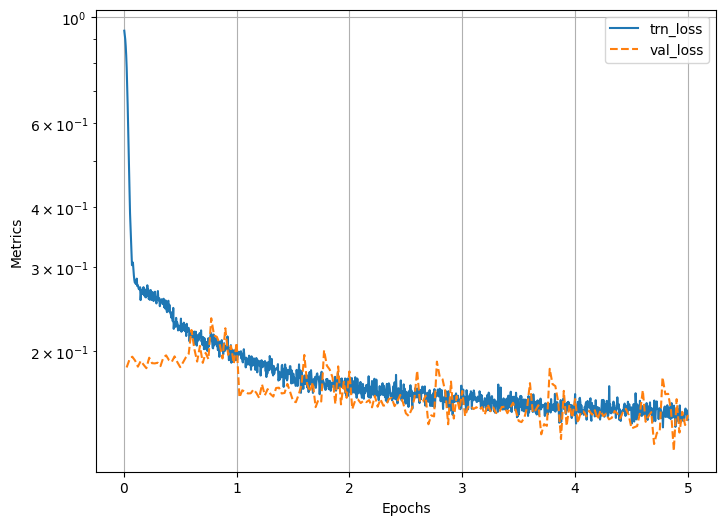

In [9]:
model = AutoEncoder(3).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)

num_epochs = 5
log = Report(num_epochs)

for epoch in range(num_epochs):
    N = len(trn_dl)
    for ix, (data, _) in enumerate(trn_dl):
        loss = train_batch(data, model, criterion, optimizer)
        log.record(pos=(epoch + (ix+1)/N), trn_loss=loss, end='\r')

    N = len(val_dl)
    for ix, (data, _) in enumerate(val_dl):
        loss = validate_batch(data, model, criterion)
        log.record(pos=(epoch + (ix+1)/N), val_loss=loss, end='\r')
    log.report_avgs(epoch+1)
log.plot(log=True)

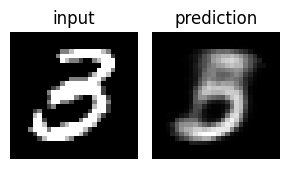

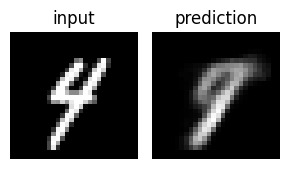

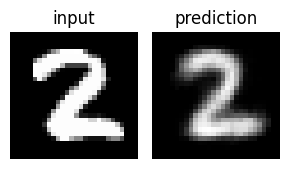

In [11]:
import matplotlib.pyplot as plt

for _ in range(3):
    ix = np.random.randint(len(val_ds))
    im, _ = val_ds[ix]
    _im = model(im[None])[0]
    fig, ax = plt.subplots(1,2,figsize=(3,3))
    show(im[0], ax=ax[0], title='input')
    show(_im[0], ax=ax[1], title='prediction')
    plt.tight_layout()
    plt.show()

EPOCH: 1.000  trn_loss: 0.231  val_loss: 0.133  (19.55s - 78.20s remaining)
EPOCH: 2.000  trn_loss: 0.113  val_loss: 0.095  (39.82s - 59.73s remaining)
EPOCH: 3.000  trn_loss: 0.088  val_loss: 0.081  (58.80s - 39.20s remaining)
EPOCH: 4.000  trn_loss: 0.078  val_loss: 0.071  (78.74s - 19.68s remaining)
EPOCH: 5.000  trn_loss: 0.069  val_loss: 0.064  (97.53s - 0.00s remaining)


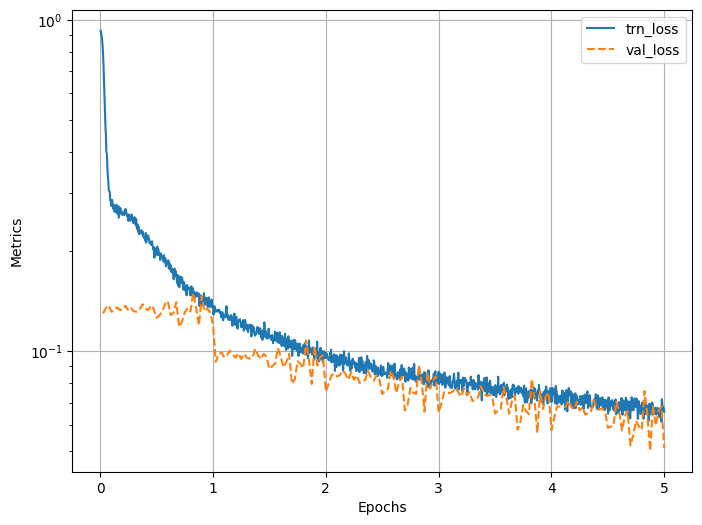

EPOCH: 1.000  trn_loss: 0.264  val_loss: 0.208  (19.37s - 77.48s remaining)
EPOCH: 2.000  trn_loss: 0.198  val_loss: 0.190  (38.20s - 57.29s remaining)
EPOCH: 3.000  trn_loss: 0.186  val_loss: 0.182  (57.53s - 38.36s remaining)
EPOCH: 4.000  trn_loss: 0.179  val_loss: 0.176  (76.24s - 19.06s remaining)
EPOCH: 5.000  trn_loss: 0.174  val_loss: 0.173  (96.24s - 0.00s remaining)


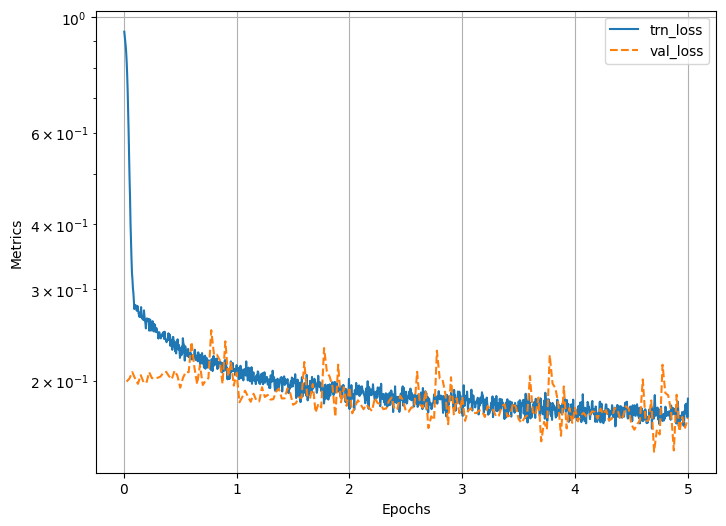

EPOCH: 1.000  trn_loss: 0.262  val_loss: 0.196  (20.38s - 81.53s remaining)
EPOCH: 2.000  trn_loss: 0.178  val_loss: 0.167  (40.11s - 60.16s remaining)
EPOCH: 3.000  trn_loss: 0.161  val_loss: 0.157  (60.33s - 40.22s remaining)
EPOCH: 4.000  trn_loss: 0.154  val_loss: 0.151  (80.83s - 20.21s remaining)
EPOCH: 5.000  trn_loss: 0.149  val_loss: 0.148  (100.73s - 0.00s remaining)


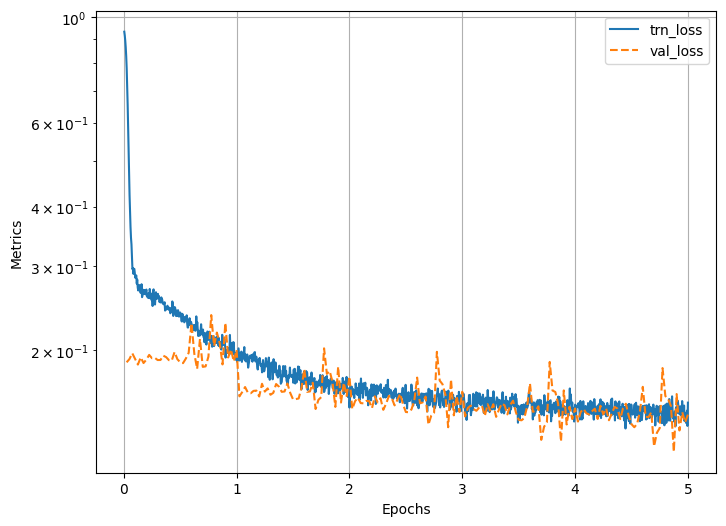

EPOCH: 1.000  trn_loss: 0.264  val_loss: 0.180  (20.63s - 82.53s remaining)
EPOCH: 2.000  trn_loss: 0.155  val_loss: 0.142  (41.15s - 61.73s remaining)
EPOCH: 3.000  trn_loss: 0.134  val_loss: 0.128  (61.18s - 40.79s remaining)
EPOCH: 4.000  trn_loss: 0.125  val_loss: 0.123  (81.53s - 20.38s remaining)
EPOCH: 5.000  trn_loss: 0.120  val_loss: 0.118  (101.71s - 0.00s remaining)


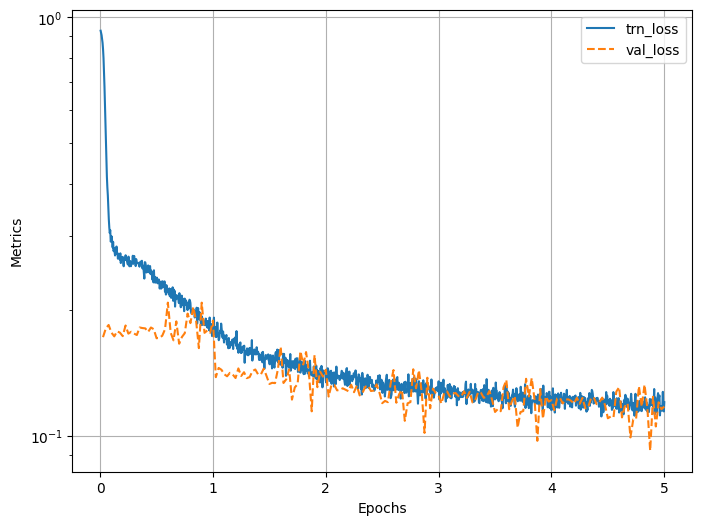

EPOCH: 1.000  trn_loss: 0.247  val_loss: 0.152  (20.40s - 81.61s remaining)
EPOCH: 2.000  trn_loss: 0.131  val_loss: 0.113  (40.81s - 61.22s remaining)
EPOCH: 3.000  trn_loss: 0.107  val_loss: 0.100  (60.48s - 40.32s remaining)
EPOCH: 4.000  trn_loss: 0.099  val_loss: 0.095  (80.63s - 20.16s remaining)
EPOCH: 5.000  trn_loss: 0.095  val_loss: 0.091  (100.93s - 0.00s remaining)


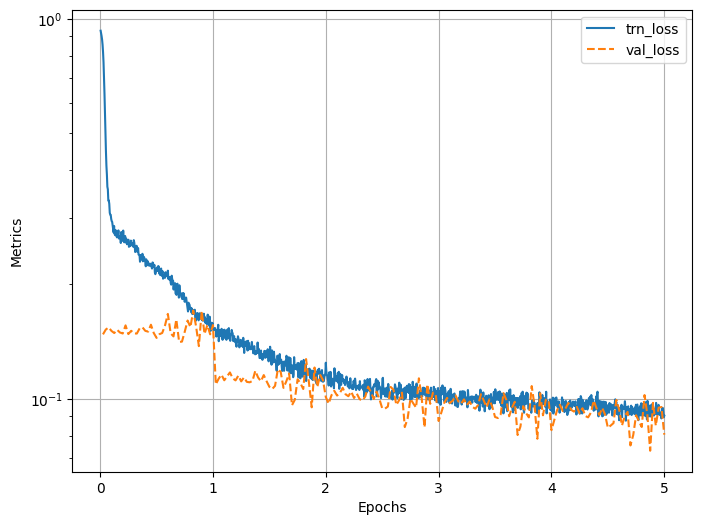

In [12]:
def train_aec(latent_dim):
    model = AutoEncoder(latent_dim).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)

    num_epochs = 5
    log = Report(num_epochs)

    for epoch in range(num_epochs):
        N = len(trn_dl)
        for ix, (data, _) in enumerate(trn_dl):
            loss = train_batch(data, model, criterion, optimizer)
            log.record(pos=(epoch + (ix+1)/N), trn_loss=loss, end='\r')

        N = len(val_dl)
        for ix, (data, _) in enumerate(val_dl):
            loss = validate_batch(data, model, criterion)
            log.record(pos=(epoch + (ix+1)/N), val_loss=loss, end='\r')
        log.report_avgs(epoch+1)
    log.plot(log=True)
    return model

aecs = [train_aec(dim) for dim in [50, 2, 3, 5, 10]]

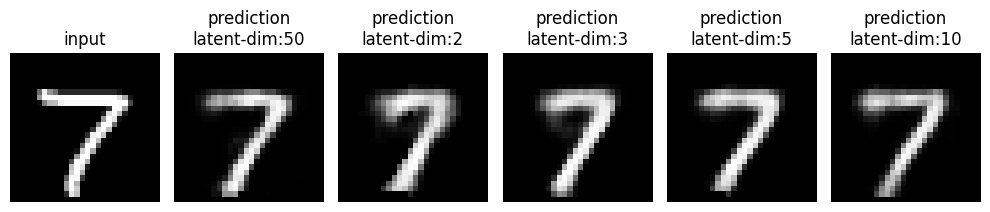

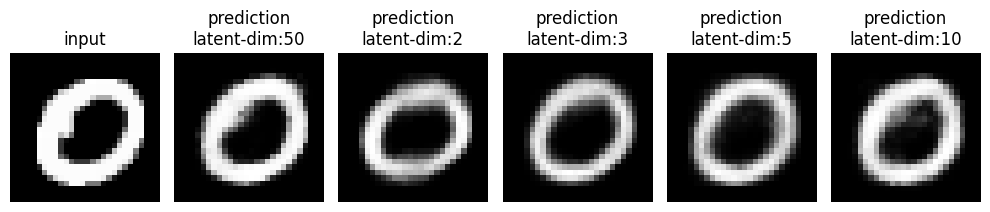

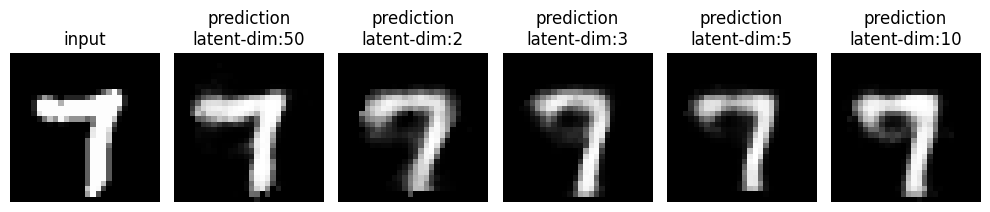

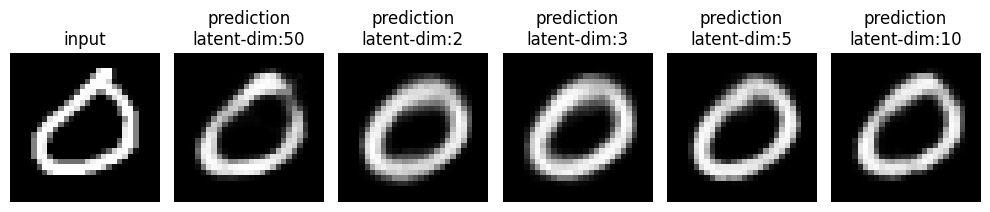

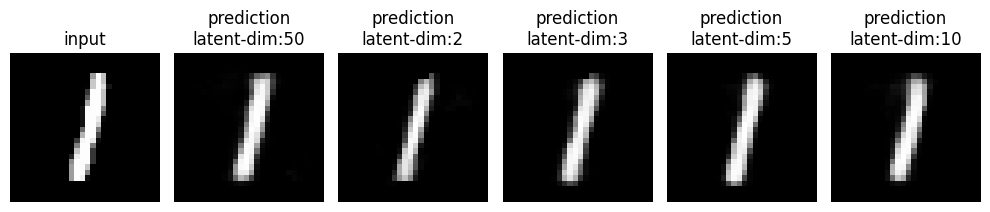

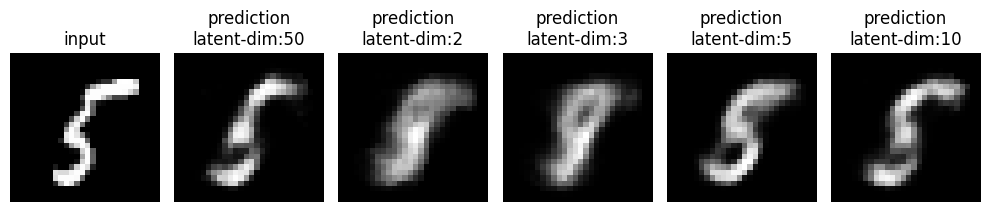

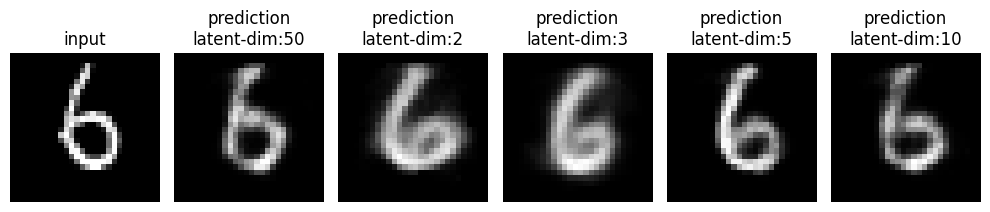

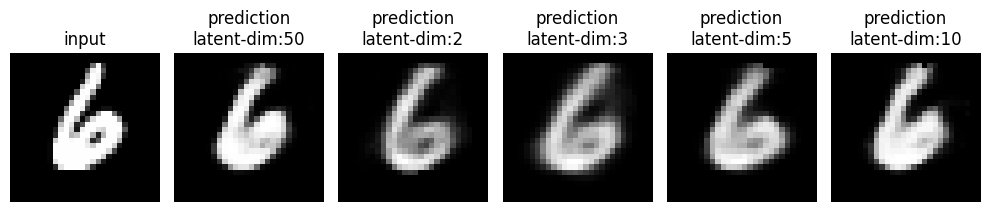

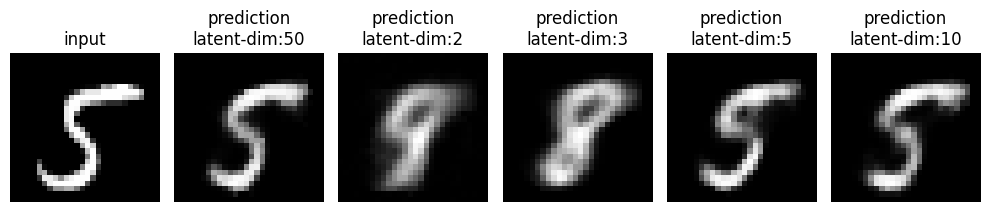

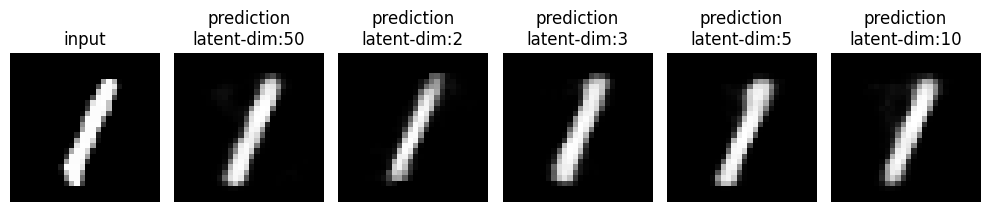

In [13]:
for _ in range(10):
    ix = np.random.randint(len(val_ds))
    im, _ = val_ds[ix]
    fig, ax = plt.subplots(1, len(aecs)+1, figsize=(10,4))
    ax = iter(ax.flat)
    show(im[0], ax=next(ax), title='input')
    for model in aecs:
        _im = model(im[None])[0]
        show(_im[0], ax=next(ax), title=f'prediction\nlatent-dim:{model.latend_dim}')
    plt.tight_layout()
    plt.show()